# GCN Fraud Detection on the Elliptic Bitcoin Dataset

This notebook implements a **Graph Convolutional Network (GCN)** for Bitcoin fraud detection using the original Elliptic Bitcoin dataset.

## Pipeline
1. Load & preprocess elliptic_bitcoin_data (transactions only)
2. Build PyG `Data` objects per time step
3. Train a GCN with temporal split (steps 1–34 train, 35–39 validation, 40–49 test)
   - The scaler is fit only on the training time window
4. Evaluate: F1 (illicit), Precision, Recall, AUC-ROC
5. Visualize results

In [1]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['font.size'] = 12
plt.style.use('ggplot')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, BatchNorm
from torch_geometric.utils import to_undirected

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler

# ── Paths ──
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'raw' / 'elliptic_bitcoin_data').exists():
            return candidate
    raise FileNotFoundError('Could not find project root containing data/raw/elliptic_bitcoin_data')


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'elliptic_bitcoin_data'
FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'elliptic_bitcoin_data'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Auto-detect nested subfolder
for candidate in [DATA_DIR, DATA_DIR / 'elliptic_bitcoin_dataset']:
    if (candidate / 'elliptic_txs_features.csv').is_file():
        DATA_DIR = candidate
        break

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'Data   : {DATA_DIR.resolve()}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/kuijun_2/miniconda3/envs/fraud-detection-gnn/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/kuijun_2/miniconda3/envs/fraud-detection-gnn/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/kuijun_2/miniconda3/envs/fraud-detection-gnn/lib/python3.11/site-packages/i

Device : cpu
PyTorch: 2.1.2
Data   : /Users/kuijun_2/Desktop/spring-2026-spec-proj/data/raw/elliptic_bitcoin_data/elliptic_bitcoin_dataset


## 1. Load Data

In [2]:
# ── Load raw CSVs ──
features_df = pd.read_csv(
    os.path.join(DATA_DIR, 'elliptic_txs_features.csv'),
    header=None,
    dtype={0: np.int64, **{i: np.float32 for i in range(1, 167)}}
)
classes_df  = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_classes.csv'))
edgelist_df = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_edgelist.csv'))

# Column naming: col-0 = txId, col-1 = time_step, cols 2..94 = local, 95..166 = agg
NUM_AGG   = 72
NUM_LOCAL = features_df.shape[1] - 2 - NUM_AGG   # 93
feat_names = (
    ['txId', 'time_step']
    + [f'local_{i}' for i in range(NUM_LOCAL)]
    + [f'agg_{i}'   for i in range(NUM_AGG)]
)
features_df.columns = feat_names

# Merge class labels
df = features_df.merge(classes_df, on='txId', how='left')
df['label'] = df['class'].map({'1': 1, '2': 0, 'unknown': -1}).astype(int)

print(f'Features : {features_df.shape}')
print(f'Edgelist : {edgelist_df.shape}')
print(f'Classes  : {df["label"].value_counts().to_dict()}  (1=illicit, 0=licit, -1=unknown)')

Features : (203769, 167)
Edgelist : (234355, 2)
Classes  : {-1: 157205, 0: 42019, 1: 4545}  (1=illicit, 0=licit, -1=unknown)


## 2. Preprocessing & Graph Construction

We keep the split chronological: early time steps are used for fitting the feature scaler,
a validation window is used for model selection, and later time steps are reserved for final test evaluation.
Unlabeled nodes stay in the graph as context.

In [3]:
# ── Feature columns (local + aggregated) ──
FEAT_COLS = [c for c in df.columns if c.startswith('local_') or c.startswith('agg_')]
print(f'Feature dimension: {len(FEAT_COLS)}')

# ── Global node index mapping  txId → integer index ──
all_tx_ids = df['txId'].values
tx2idx = {tx: i for i, tx in enumerate(all_tx_ids)}

# Temporal split: train = time steps 1-34, val = time steps 35-39, test = time steps 40-49.
# Fit the scaler on the training window only to avoid future leakage.
# ── Scale features (fit on labeled training nodes only) ──
TRAIN_STEPS = list(range(1, 35))   # time steps 1-34  (~70 %)
VAL_STEPS   = list(range(35, 40))  # time steps 35-39  (~15 %)
TEST_STEPS  = list(range(40, 50))  # time steps 40-49 (~15 %)

train_mask = df['time_step'].isin(TRAIN_STEPS)
scaler = StandardScaler()
scaler.fit(df.loc[train_mask, FEAT_COLS].values)

X_scaled = scaler.transform(df[FEAT_COLS].values).astype(np.float32)
print('Feature scaling done.')

# ── Build edge_index (global, directed → convert to undirected) ──
src = edgelist_df['txId1'].map(tx2idx).dropna().astype(int).values
dst = edgelist_df['txId2'].map(tx2idx).dropna().astype(int).values

# Keep only edges where BOTH endpoints are in our node set
valid_mask = (
    edgelist_df['txId1'].isin(tx2idx) &
    edgelist_df['txId2'].isin(tx2idx)
).values
src = edgelist_df.loc[valid_mask, 'txId1'].map(tx2idx).values.astype(np.int64)
dst = edgelist_df.loc[valid_mask, 'txId2'].map(tx2idx).values.astype(np.int64)

edge_index = torch.tensor(np.stack([src, dst], axis=0), dtype=torch.long)
edge_index = to_undirected(edge_index)   # symmetrise
print(f'Edge index shape: {edge_index.shape}  (undirected)')

Feature dimension: 165


Feature scaling done.
Edge index shape: torch.Size([2, 468710])  (undirected)


In [4]:
# ── Build a SINGLE global PyG Data object ──
# Masks: train  = labeled nodes in train steps
#        val    = labeled nodes in validation steps
#        test   = labeled nodes in test steps
#        (unlabeled nodes with label==-1 remain as graph context, but do not enter the loss)

labels = torch.tensor(df['label'].values, dtype=torch.long)
x      = torch.tensor(X_scaled, dtype=torch.float)

train_mask_t = torch.tensor(
    (df['time_step'].isin(TRAIN_STEPS) & (df['label'] != -1)).tolist(), dtype=torch.bool
)
val_mask_t  = torch.tensor(
    (df['time_step'].isin(VAL_STEPS)  & (df['label'] != -1)).tolist(), dtype=torch.bool
)
test_mask_t  = torch.tensor(
    (df['time_step'].isin(TEST_STEPS)  & (df['label'] != -1)).tolist(), dtype=torch.bool
)

data = Data(
    x          = x,
    edge_index = edge_index,
    y          = labels,
    train_mask = train_mask_t,
    val_mask   = val_mask_t,
    test_mask  = test_mask_t,
)
data = data.to(DEVICE)

print(data)
print(f'Train labeled nodes: {train_mask_t.sum().item():,}')
print(f'Val   labeled nodes: {val_mask_t.sum().item():,}')
print(f'Test  labeled nodes: {test_mask_t.sum().item():,}')

# Class imbalance weight for loss
y_train = labels[train_mask_t]
n_licit   = (y_train == 0).sum().item()
n_illicit = (y_train == 1).sum().item()
pos_weight = torch.tensor([n_licit / n_illicit], dtype=torch.float).to(DEVICE)
print(f'Illicit/Licit in train: {n_illicit:,} / {n_licit:,}  →  pos_weight = {pos_weight.item():.2f}')

Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Train labeled nodes: 29,894
Val   labeled nodes: 5,486
Test  labeled nodes: 11,184
Illicit/Licit in train: 3,462 / 26,432  →  pos_weight = 7.63


## 3. GCN Model Definition

In [5]:
class GCN(nn.Module):
    """
    3-layer GCN with:
      - BatchNorm after each conv
      - Dropout for regularisation
      - Skip connection from input to final layer
    """
    def __init__(self, in_channels, hidden_channels, out_channels=2,
                 dropout=0.4, num_layers=3):
        super().__init__()
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        dims = [in_channels] + [hidden_channels] * (num_layers - 1) + [hidden_channels]
        for i in range(num_layers):
            self.convs.append(GCNConv(dims[i], dims[i + 1]))
            self.bns.append(BatchNorm(dims[i + 1]))

        # Final classifier head
        self.lin = nn.Linear(hidden_channels + in_channels, out_channels)

    def forward(self, x, edge_index):
        x0 = x  # keep for skip connection
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        # Skip connection
        x = torch.cat([x, x0], dim=-1)
        return self.lin(x)


# ── Hyper-parameters ──
IN_CHANNELS     = len(FEAT_COLS)   # 165
HIDDEN_CHANNELS = 128
NUM_LAYERS      = 3
DROPOUT         = 0.4
LR              = 1e-3
WEIGHT_DECAY    = 5e-4
EPOCHS          = 200
PATIENCE        = 20

model = GCN(
    in_channels     = IN_CHANNELS,
    hidden_channels = HIDDEN_CHANNELS,
    num_layers      = NUM_LAYERS,
    dropout         = DROPOUT,
).to(DEVICE)

optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

# Weighted cross-entropy to handle class imbalance
# weight[0]=licit, weight[1]=illicit
class_weight = torch.tensor([1.0, pos_weight.item()], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weight)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

GCN(
  (convs): ModuleList(
    (0): GCNConv(165, 128)
    (1-2): 2 x GCNConv(128, 128)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm(128)
  )
  (lin): Linear(in_features=293, out_features=2, bias=True)
)

Trainable parameters: 55,628


## 4. Training

In [6]:
def train_epoch(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out    = model(data.x, data.edge_index)
    probs  = F.softmax(out[mask], dim=-1)[:, 1].detach().cpu().tolist()
    preds  = out[mask].argmax(dim=-1).detach().cpu().tolist()
    labels = data.y[mask].detach().cpu().tolist()
    f1  = f1_score(labels, preds, pos_label=1, zero_division=0)
    auc = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else 0.0
    return f1, auc, preds, probs, labels


# ── Training loop ──
history = {'loss': [], 'train_f1': [], 'val_f1': [], 'val_auc': [], 'test_f1': [], 'test_auc': []}
best_val_f1    = 0.0
best_epoch     = 0
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, data, optimizer, criterion)
    tr_f1, tr_auc, _, _, _ = evaluate(model, data, data.train_mask)
    va_f1, va_auc, _, _, _ = evaluate(model, data, data.val_mask)
    te_f1, te_auc, _, _, _ = evaluate(model, data, data.test_mask)

    scheduler.step(va_f1)

    history['loss'].append(loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(va_f1)
    history['val_auc'].append(va_auc)
    history['test_f1'].append(te_f1)
    history['test_auc'].append(te_auc)

    if va_f1 > best_val_f1:
        best_val_f1   = va_f1
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'gcn_elliptic_best.pt'))
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Loss {loss:.4f} | '
              f'Train F1 {tr_f1:.4f} | Val F1 {va_f1:.4f} | Test F1 {te_f1:.4f}')

print(f'\nBest Val F1 = {best_val_f1:.4f} at epoch {best_epoch}')

Epoch   1 | Loss 0.6292 | Train F1 0.4218 | Val F1 0.2570 | Test F1 0.1436
Epoch  20 | Loss 0.2942 | Train F1 0.5726 | Val F1 0.3114 | Test F1 0.1788
Epoch  40 | Loss 0.2569 | Train F1 0.6112 | Val F1 0.3202 | Test F1 0.1744
Epoch  60 | Loss 0.2414 | Train F1 0.6338 | Val F1 0.3356 | Test F1 0.1813
Epoch  80 | Loss 0.2352 | Train F1 0.6453 | Val F1 0.3375 | Test F1 0.1820
Epoch 100 | Loss 0.2284 | Train F1 0.6507 | Val F1 0.3400 | Test F1 0.1835
Epoch 120 | Loss 0.2225 | Train F1 0.6587 | Val F1 0.3427 | Test F1 0.1836
Epoch 140 | Loss 0.2185 | Train F1 0.6644 | Val F1 0.3454 | Test F1 0.1844
Early stopping at epoch 151

Best Val F1 = 0.3477 at epoch 131


## 5. Evaluation

In [7]:
# Load best checkpoint selected by validation F1
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'gcn_elliptic_best.pt'), map_location=DEVICE))

_, _, preds_val, probs_val, labels_val = evaluate(model, data, data.val_mask)
_, _, preds_test, probs_test, labels_test = evaluate(model, data, data.test_mask)
_, _, preds_train, probs_train, labels_train = evaluate(model, data, data.train_mask)

print('=' * 55)
print('VALIDATION SET — Classification Report')
print('=' * 55)
print(classification_report(labels_val, preds_val, target_names=['Licit', 'Illicit']))

val_f1  = f1_score(labels_val, preds_val, pos_label=1, zero_division=0)
val_prec = precision_score(labels_val, preds_val, pos_label=1, zero_division=0)
val_rec  = recall_score(labels_val, preds_val, pos_label=1, zero_division=0)
val_auc  = roc_auc_score(labels_val, probs_val)

print(f'Illicit F1        : {val_f1:.4f}')
print(f'Illicit Precision : {val_prec:.4f}')
print(f'Illicit Recall    : {val_rec:.4f}')
print(f'ROC-AUC           : {val_auc:.4f}')

print('\nTEST SET — Classification Report')
print('=' * 55)
print(classification_report(labels_test, preds_test, target_names=['Licit', 'Illicit']))

test_f1  = f1_score(labels_test, preds_test, pos_label=1, zero_division=0)
test_prec = precision_score(labels_test, preds_test, pos_label=1, zero_division=0)
test_rec  = recall_score(labels_test, preds_test, pos_label=1, zero_division=0)
test_auc  = roc_auc_score(labels_test, probs_test)

print(f'Illicit F1        : {test_f1:.4f}')
print(f'Illicit Precision : {test_prec:.4f}')
print(f'Illicit Recall    : {test_rec:.4f}')
print(f'ROC-AUC           : {test_auc:.4f}')

VALIDATION SET — Classification Report
              precision    recall  f1-score   support

       Licit       1.00      0.68      0.81      5039
     Illicit       0.21      0.98      0.35       447

    accuracy                           0.70      5486
   macro avg       0.60      0.83      0.58      5486
weighted avg       0.93      0.70      0.77      5486

Illicit F1        : 0.3477
Illicit Precision : 0.2114
Illicit Recall    : 0.9776
ROC-AUC           : 0.9262

TEST SET — Classification Report
              precision    recall  f1-score   support

       Licit       0.98      0.61      0.75     10548
     Illicit       0.11      0.78      0.19       636

    accuracy                           0.62     11184
   macro avg       0.54      0.69      0.47     11184
weighted avg       0.93      0.62      0.72     11184

Illicit F1        : 0.1868
Illicit Precision : 0.1062
Illicit Recall    : 0.7767
ROC-AUC           : 0.8112


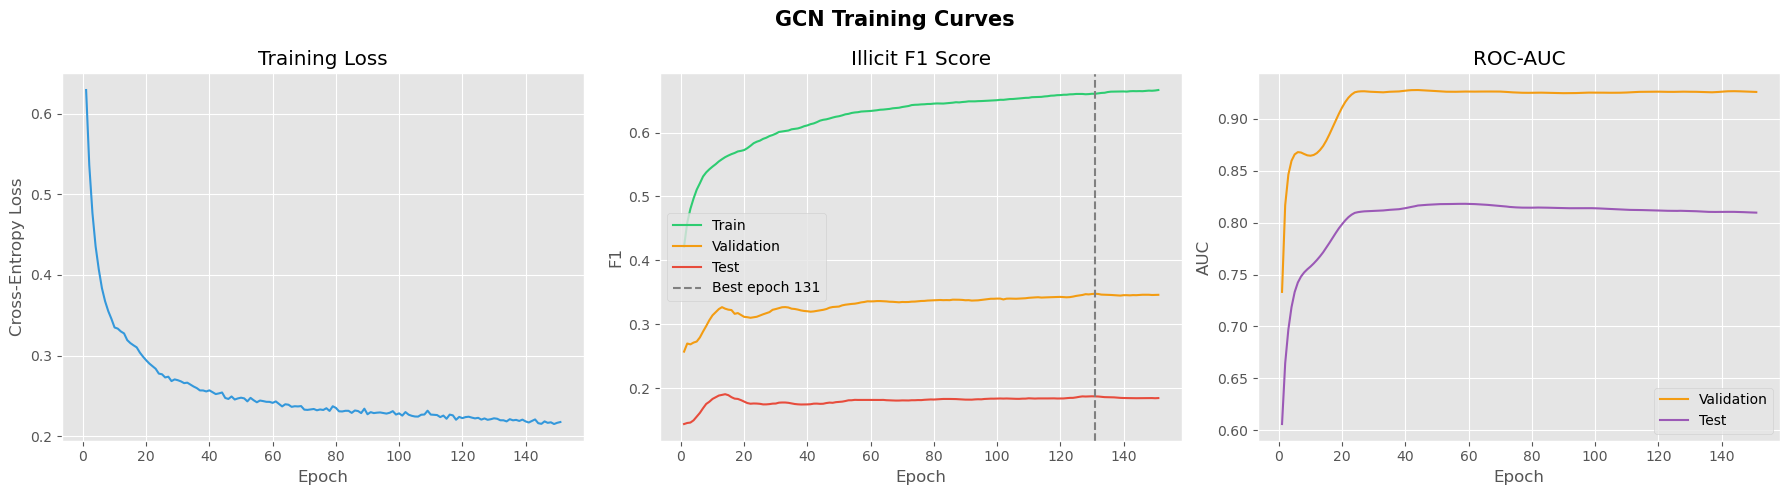

In [8]:
# ── Training Curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GCN Training Curves', fontsize=15, fontweight='bold')

epochs_range = range(1, len(history['loss']) + 1)

axes[0].plot(epochs_range, history['loss'], color='#3498db')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')

axes[1].plot(epochs_range, history['train_f1'], label='Train', color='#2ecc71')
axes[1].plot(epochs_range, history['val_f1'],    label='Validation', color='#f39c12')
axes[1].plot(epochs_range, history['test_f1'],   label='Test',  color='#e74c3c')
axes[1].axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch {best_epoch}')
axes[1].set_title('Illicit F1 Score')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].legend()

axes[2].plot(epochs_range, history['val_auc'],  label='Validation', color='#f39c12')
axes[2].plot(epochs_range, history['test_auc'], label='Test', color='#9b59b6')
axes[2].set_title('ROC-AUC')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gcn_training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

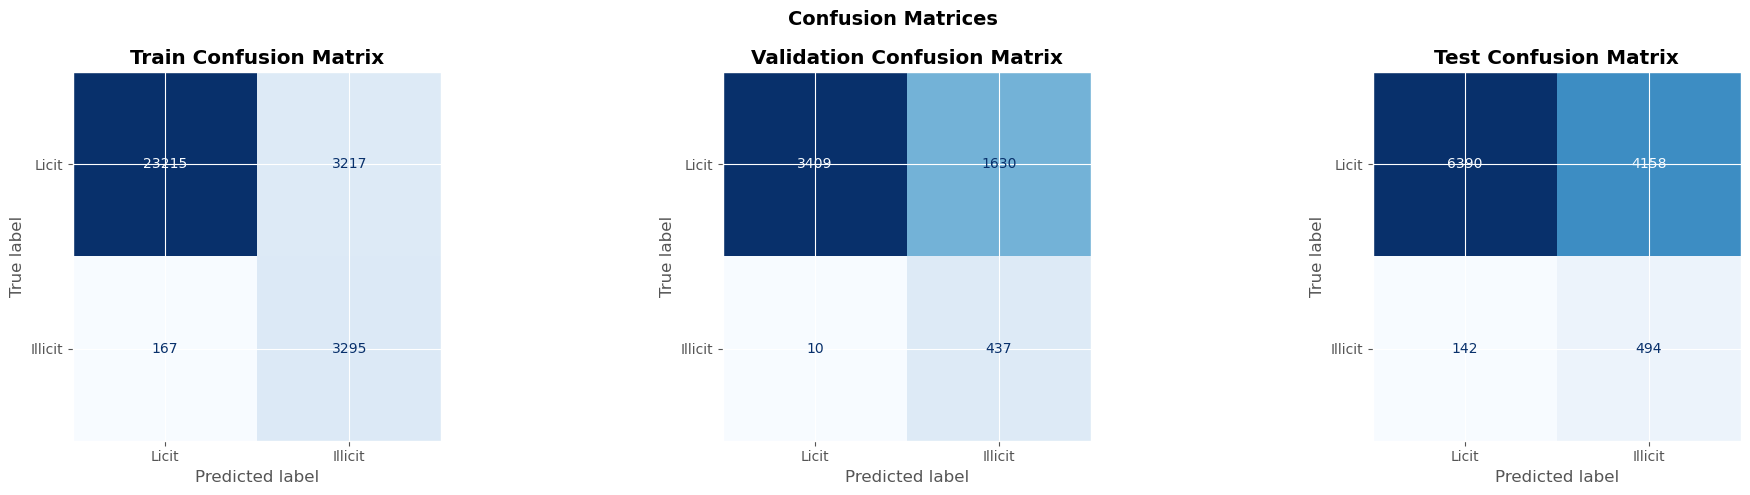

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, preds, labels, title in [
    (axes[0], preds_train, labels_train, 'Train'),
    (axes[1], preds_val,   labels_val,   'Validation'),
    (axes[2], preds_test,  labels_test,  'Test'),
]:
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Licit', 'Illicit'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gcn_confusion_matrices.png'), dpi=200, bbox_inches='tight')
plt.show()

 step       f1  precision   recall      auc
   40 0.275580   0.162641 0.901786 0.864243
   41 0.314483   0.187192 0.982759 0.909576
   42 0.364366   0.225422 0.949791 0.923015
   43 0.035714   0.018382 0.625000 0.457993
   44 0.028571   0.014793 0.416667 0.557860
   45 0.017316   0.008850 0.400000 0.696875
   46 0.009975   0.005013 1.000000 0.961972
   47 0.036530   0.020305 0.181818 0.595102
   48 0.337349   0.297872 0.388889 0.865006
   49 0.090909   0.092593 0.089286 0.671896


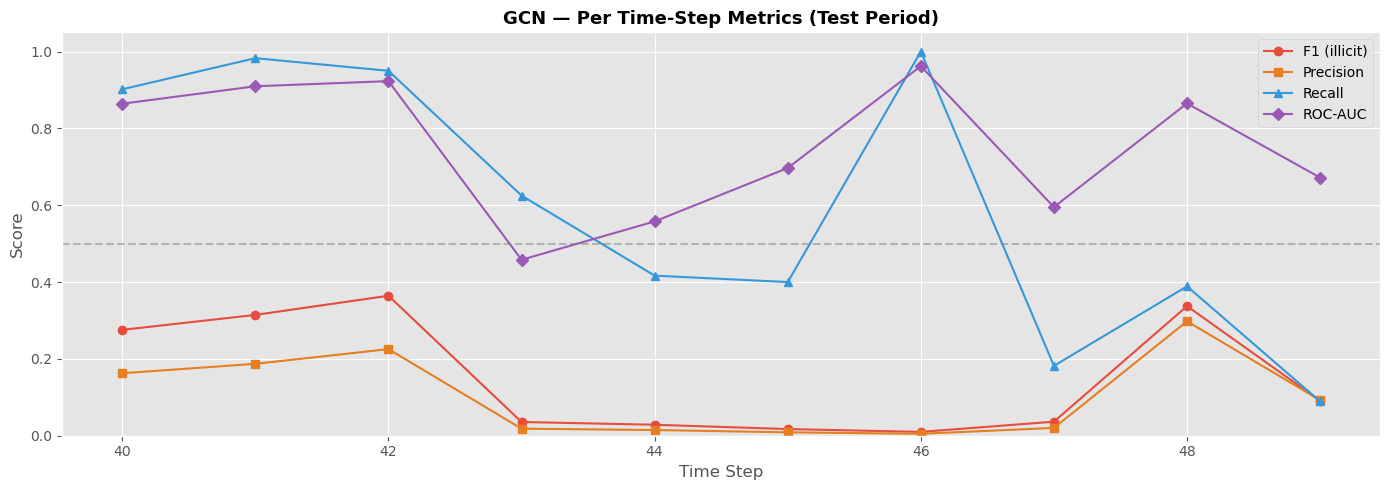

In [10]:
# ── F1 per Time Step (test period) ──
model.eval()
with torch.no_grad():
    out_all   = model(data.x, data.edge_index)
    preds_all = np.asarray(out_all.argmax(dim=-1).detach().cpu().tolist())
    probs_all = np.asarray(F.softmax(out_all, dim=-1)[:, 1].detach().cpu().tolist())

labels_all = df['label'].values
steps_all  = df['time_step'].values

step_metrics = []
for s in TEST_STEPS:
    mask_s = (steps_all == s) & (labels_all != -1)
    if mask_s.sum() == 0:
        continue
    y_s = labels_all[mask_s]
    p_s = preds_all[mask_s]
    pr_s = probs_all[mask_s]
    if len(np.unique(y_s)) < 2:
        continue
    step_metrics.append({
        'step': s,
        'f1':        f1_score(y_s, p_s, pos_label=1, zero_division=0),
        'precision': precision_score(y_s, p_s, pos_label=1, zero_division=0),
        'recall':    recall_score(y_s, p_s, pos_label=1, zero_division=0),
        'auc':       roc_auc_score(y_s, pr_s),
    })

metrics_df = pd.DataFrame(step_metrics)
print(metrics_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(metrics_df['step'], metrics_df['f1'],        marker='o', label='F1 (illicit)',  color='#e74c3c')
ax.plot(metrics_df['step'], metrics_df['precision'], marker='s', label='Precision',     color='#e67e22')
ax.plot(metrics_df['step'], metrics_df['recall'],    marker='^', label='Recall',        color='#3498db')
ax.plot(metrics_df['step'], metrics_df['auc'],       marker='D', label='ROC-AUC',       color='#9b59b6')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_title('GCN — Per Time-Step Metrics (Test Period)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step'); ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gcn_per_step_metrics.png'), dpi=200, bbox_inches='tight')
plt.show()

## 6. Summary

In [11]:
print('=' * 55)
print('GCN on Elliptic Bitcoin — Final Summary')
print('=' * 55)
print(f'Architecture  : {NUM_LAYERS}-layer GCN + skip connection')
print(f'Hidden dim    : {HIDDEN_CHANNELS}')
print(f'Features      : {IN_CHANNELS}')
print(f'Train steps   : 1–34')
print(f'Val   steps   : 35–39')
print(f'Test  steps   : 40–49')
print(f'Best epoch    : {best_epoch}')
print(f'Best Val F1    : {best_val_f1:.4f}')
print()
print(f'Validation Illicit F1        : {val_f1:.4f}')
print(f'Validation Illicit Precision : {val_prec:.4f}')
print(f'Validation Illicit Recall    : {val_rec:.4f}')
print(f'Validation ROC-AUC           : {val_auc:.4f}')
print()
print(f'Test Illicit F1        : {test_f1:.4f}')
print(f'Test Illicit Precision : {test_prec:.4f}')
print(f'Test Illicit Recall    : {test_rec:.4f}')
print(f'Test ROC-AUC           : {test_auc:.4f}')
print()
print(f'Per-step mean F1  : {metrics_df["f1"].mean():.4f} ± {metrics_df["f1"].std():.4f}')
print(f'Per-step mean AUC : {metrics_df["auc"].mean():.4f} ± {metrics_df["auc"].std():.4f}')

GCN on Elliptic Bitcoin — Final Summary
Architecture  : 3-layer GCN + skip connection
Hidden dim    : 128
Features      : 165
Train steps   : 1–34
Val   steps   : 35–39
Test  steps   : 40–49
Best epoch    : 131
Best Val F1    : 0.3477

Validation Illicit F1        : 0.3477
Validation Illicit Precision : 0.2114
Validation Illicit Recall    : 0.9776
Validation ROC-AUC           : 0.9262

Test Illicit F1        : 0.1868
Test Illicit Precision : 0.1062
Test Illicit Recall    : 0.7767
Test ROC-AUC           : 0.8112

Per-step mean F1  : 0.1511 ± 0.1510
Per-step mean AUC : 0.7504 ± 0.1769
